In [ ]:
# del F
import pickle
from timeit import default_timer

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Adam import Adam
from utilities3 import *


torch.manual_seed(2)
np.random.seed(2)

if torch.cuda.is_available():
    print("CUDA is available. GPU will be used.")
    device = torch.device("cuda:3")
else:
    print("CUDA is not available. CPU will be used.")
    device = torch.device("cpu")

CUDA is available. GPU will be used.


Vanila $\psi$- FNO

In [ ]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_high):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_high = (
            modes_high  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        )

        self.scale = 1 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            self.scale
            * torch.rand(in_channels, out_channels, self.modes_high, dtype=torch.cfloat)
        )

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        if len(input.shape) == 3:
            return torch.einsum("bix,iox->box", input, weights)
        elif len(input.shape) == 4:
            return torch.einsum("dbix,iox->dbox", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        Nt = x.shape[1]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        if len(x.shape) == 3:
            out_ft = torch.zeros(
                batchsize,
                self.out_channels,
                x.size(-1) // 2 + 1,
                device=x.device,
                dtype=torch.cfloat,
            )
            out_ft[:, :, : self.modes_high :] = self.compl_mul1d(
                x_ft[:, :, : self.modes_high], self.weights
            )
        elif len(x.shape) == 4:
            out_ft = torch.zeros(
                batchsize,
                Nt,
                self.out_channels,
                x.size(-1) // 2 + 1,
                device=x.device,
                dtype=torch.cfloat,
            )
            out_ft[:, :, :, : self.modes_high :] = self.compl_mul1d(
                x_ft[:, :, :, : self.modes_high], self.weights
            )
        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


class FNO1d(nn.Module):
    def __init__(self, modes_high, width, depth, kernz, noise_dim=1):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes_high = modes_high
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 2  # pad the domain if input is non-periodic
        self.noise_dim = noise_dim
        self.fc0 = nn.Linear(
            1 + self.noise_dim, self.width, bias=False
        )  # input channel is 2: (a(x), x)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.modes_high)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )
        self.noise_dim = noise_dim

        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128, bias=False)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        # x0 = x

        for i in range(self.depth):
            x1 = self.fouriers[i](x)
            # x2 = self.convs[i](x)

            # x = self.relu(x1 + x2 + x0)
            # x0 = x
            x = self.relu(x1)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

    def forward_k(self, x, k):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        for i in range(k):
            x1 = self.fouriers[i](x)

            x = x1

        return x

    def forward_k_act(self, x, k):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        for i in range(k):
            x1 = self.fouriers[i](x)

            x = self.relu(x1)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

In [ ]:
# %%
################################################################
# fourier layer
################################################################
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = (
            modes1  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        )
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale
            * torch.rand(
                in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat
            )
        )
        self.weights2 = nn.Parameter(
            self.scale
            * torch.rand(
                in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat
            )
        )

    # Complex multiplication
    def compl_mul2d(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, : self.modes1, : self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1 :, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1 :, : self.modes2], self.weights2
        )

        # Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x


class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(FNO2d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the coefficient function and locations (a(x, y), x, y)
        input shape: (batchsize, x=s, y=s, c=3)
        output: the solution 
        output shape: (batchsize, x=s, y=s, c=1)
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.fc0 = nn.Linear(3, self.width)  # input channel is 3: (a(x, y), x, y)

        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.modes_high)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )
        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        batchsize = x.shape[0]
        size_x, size_y = x.shape[1], x.shape[2]

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        x1 = self.conv0(x)
        x2 = self.w0(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        x = self.relu(x)

        x1 = self.conv1(x)
        x2 = self.w1(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        x = self.relu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        x = self.relu(x)

        x1 = self.conv3(x)
        x2 = self.w3(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2

        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x


# %%

In [ ]:
class ContextFNO(nn.Module):
    def __init__(self, modes1, modes2, mode1d, width, depth):
        super(ContextFNO, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the coefficient function and locations (a(x, y), x, y)
        input shape: (batchsize, x=s, y=s, c=3)
        output: the solution 
        output shape: (batchsize, x=s, y=s, c=1)
        """
        self.depth = depth
        self.mode1d = mode1d
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 18  # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(3, self.width)  # input channel is 3: (a(x, y), x, y)

        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.mode1d)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [nn.Conv1d(self.width, self.width, 1, padding=0) for i in range(self.depth)]
        )

        self.fouriers_out = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.mode1d)
                for i in range(self.depth)
            ]
        )
        self.convs_out = nn.ModuleList(
            [nn.Conv1d(self.width, self.width, 1, padding=0) for i in range(self.depth)]
        )

        self.fc00 = nn.Linear(
            3, self.width, bias=False
        )  # input channel is 2: (a(x), x)

        self.fc10 = nn.Linear(self.width, 128, bias=False)
        self.fc20 = nn.Linear(128, self.width)

        self.fc01 = nn.Linear(self.width, self.width, bias=False)
        self.fc11 = nn.Linear(self.width, 128, bias=False)
        self.fc21 = nn.Linear(128, 1)

    def forward(self, x, x0):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2

        x = x[..., : -self.padding, : -self.padding]
        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)

        grid1d = self.get_grid1d(x0.shape, x0.device)
        x0 = torch.cat((x0, grid1d), dim=-1)

        x0 = self.fc00(x0)

        x0 = x0.permute(0, 2, 1)

        for i in range(self.depth):
            x1 = self.fouriers[i](x0)
            x2 = self.convs[i](x0)

            # x = self.relu(x1 + x2 + x0)
            # x0 = x
            x0 = F.gelu(x1 + x2)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x0 = x0.permute(0, 2, 1)
        x0 = self.fc10(x0)
        x0 = F.gelu(x0)
        x0 = self.fc20(x0)

        x0 = torch.sum(x, dim=2) * x0

        x0 = self.fc01(x0)

        x0 = x0.permute(0, 2, 1)

        for i in range(self.depth):
            x1 = self.fouriers_out[i](x0)
            x2 = self.convs_out[i](x0)

            # x = self.relu(x1 + x2 + x0)
            # x0 = x
            x0 = F.gelu(x1 + x2)

        x0 = x0.permute(0, 2, 1)
        x0 = self.fc11(x0)
        x0 = F.gelu(x0)
        x0 = self.fc21(x0)

        return x0

    def train_forward(self, x, x0):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x) + x

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.gelu(x) + x

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.gelu(x) + x

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2 + x

        x = x[..., : -self.padding, : -self.padding]
        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)

        grid1d_train = self.get_grid1d_train(x0.shape, x0.device)
        x0 = torch.cat((x0, grid1d_train), dim=-1)

        x0 = self.fc00(x0)

        x0 = x0.permute(0, 2, 3, 1)

        orig_shape = x0.shape

        x0 = x0.flatten(start_dim=0, end_dim=1)
        for i in range(self.depth):
            x1 = self.fouriers[i](x0)
            x2 = self.convs[i](x0)

            # x = self.relu(x1 + x2 + x0)
            # x0 = x
            x0 = F.gelu(x1 + x2) + x0
        B, N, A, D = orig_shape
        x0 = x0.reshape(B, N, A, D)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x0 = x0.permute(0, 3, 1, 2)
        x0 = self.fc10(x0)
        x0 = F.gelu(x0)
        x0 = self.fc20(x0)

        x0 = torch.sum(x, dim=2).unsqueeze(2) + torch.sum(x, dim=2).unsqueeze(2) * x0

        x0 = self.fc01(x0)

        x0 = x0.permute(0, 2, 3, 1)

        orig_shape = x0.shape

        x0 = x0.flatten(start_dim=0, end_dim=1)

        for i in range(self.depth):
            x1 = self.fouriers_out[i](x0)
            x2 = self.convs_out[i](x0)

            # x = self.relu(x1 + x2 + x0)
            # x0 = x
            x0 = F.gelu(x1 + x2) + x0

        B, N, A, D = orig_shape
        x0 = x0.reshape(B, N, A, D)

        x0 = x0.permute(0, 3, 1, 2)
        x0 = self.fc11(x0)
        x0 = F.gelu(x0)
        x0 = self.fc21(x0)

        # print(x0.shape)
        return x0

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)

    def get_grid1d(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

    def get_grid1d_train(self, shape, device):
        batchsize, size_x, N_t = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, N_t, 1])
        return gridx.to(device)


# %%

In [ ]:
import pickle


with open(file="trainingdataset_no_source.pickle", mode="rb") as f:
    dataset = pickle.load(f)


with open(file="testdataset_no_source.pickle", mode="rb") as f:
    testset = pickle.load(f)

In [ ]:
XX = dataset[:, :, :, 0].unsqueeze(-1).to(device)
consiI = dataset[:, :, :, 1].unsqueeze(-1).to(device)

In [ ]:
xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=3)
xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=3)

In [ ]:
learning_rate = 0.001
step_size = 50
re = 3
gamma = 0.5
model = ContextFNO(16, 16, 16, 32, 4).to(device)

print(count_params(model))
lambd = 10

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=False)
myloss2 = LpLoss(size_average=False)
for ep in range(200):
    for j in range(5):
        x = XX[20 * j : 20 * (j + 1)]
        consi = consiI[20 * j : 20 * (j + 1)]
        model.train()
        t1 = default_timer()
        train_mse = 0
        train_l2 = 0
        train_l2_2 = 0

        optimizer.zero_grad()

        xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=3)
        xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=3)

        f0 = model.train_forward(x, xl)
        f1 = model.train_forward(x, xr)

        l2_tm = lambd * myloss(
            -(0.256) * (f0 - f1)[:, :, 0:99, 0],
            (torch.roll(x, -1, dims=2) - x)[:, :, 0:99, 0].detach(),
        )

        MM = model.train_forward(x, torch.cat((x, x), dim=3))

        train_l2_tm = l2_tm.item()
        l2_F = myloss(MM, consi)  # Burgers
        # l2_F_roll = myloss(torch.roll(F,128,dims=1), torch.roll(FF,128,dims=1).detach()) #Burgers
        # l2 += myloss(F, x[0].cuda()) #advection
        l2 = l2_tm + l2_F
        l2.backward()  # use the l2 relative loss
        train_l2_consi = l2_F.item()
        optimizer.step()

        print(l2_tm, l2_F)

    scheduler.step()
    model.eval()

    print(ep, train_l2_tm, train_l2_consi)

    t2 = default_timer()

4487170
tensor(205.0505, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.1988, device='cuda:3', grad_fn=<SumBackward0>)
tensor(200.9635, device='cuda:3', grad_fn=<MulBackward0>) tensor(22.2140, device='cuda:3', grad_fn=<SumBackward0>)
tensor(198.5943, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.6976, device='cuda:3', grad_fn=<SumBackward0>)
tensor(209.0432, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.2929, device='cuda:3', grad_fn=<SumBackward0>)
tensor(201.2424, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.3404, device='cuda:3', grad_fn=<SumBackward0>)
0 201.2423858642578 20.34040069580078
tensor(201.8454, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.1276, device='cuda:3', grad_fn=<SumBackward0>)
tensor(200.2830, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.4798, device='cuda:3', grad_fn=<SumBackward0>)
tensor(208.3246, device='cuda:3', grad_fn=<MulBackward0>) tensor(20.3657, device='cuda:3', grad_fn=<SumBackward0>)
tensor(200.5378, device='cuda:3', 

In [ ]:
x = dataset[:1, :, 0, 0].unsqueeze(-1).to(device)
X = dataset[:1, :, :, 0].unsqueeze(-1).to(device)
y = []
xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=2)
xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=2)
model.to(device)
f0 = model.forward(X, xl)
f1 = model.forward(X, xr)

for i in range(10):
    x = x - (0.256) * (f0 - f1)
    # y.append(x)
    xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=2)
    xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=2)

    f0 = model.forward(X, xl)
    f1 = model.forward(X, xr)

In [ ]:
x = testset[:2, :, :, 0].unsqueeze(-1).to(device)

y = []
xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=3)
xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=3)

f0 = model.train_forward(x, xl)
f1 = model.train_forward(x, xr)

for i in range(30):
    x = x - (0.256) * (f0 - f1)
    # y.append(x)
    xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=3)
    xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=3)

    f0 = model.train_forward(X, xl)
    f1 = model.train_forward(X, xr)

OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB. GPU 3 has a total capacity of 21.98 GiB of which 1.81 MiB is free. Process 134879 has 384.00 MiB memory in use. Process 1649656 has 384.00 MiB memory in use. Including non-PyTorch memory, this process has 21.21 GiB memory in use. Of the allocated memory 20.25 GiB is allocated by PyTorch, and 678.19 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

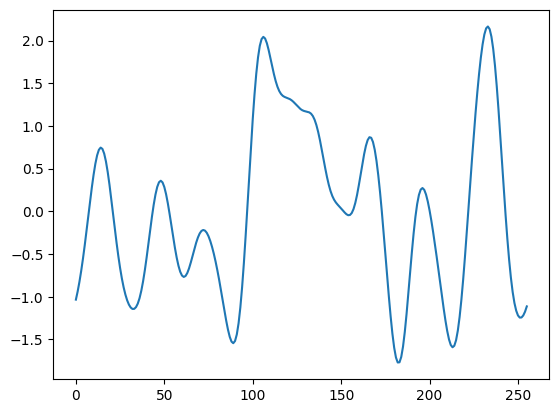

In [ ]:
plt.plot(testset.detach().cpu()[0, :, 0, 0])

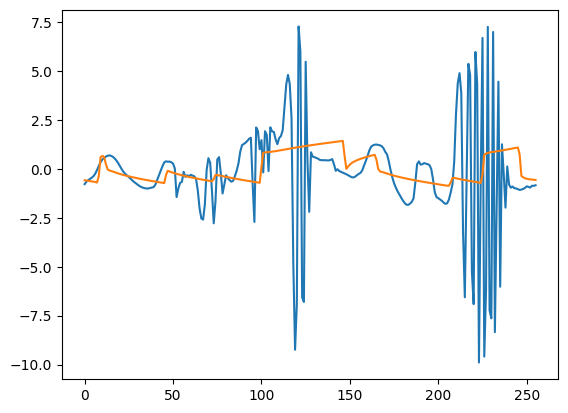

In [ ]:
M = 0
plt.plot(x.detach().cpu()[0, :, M, 0])
plt.plot(testset.detach().cpu()[0, :, M + 99, 0])

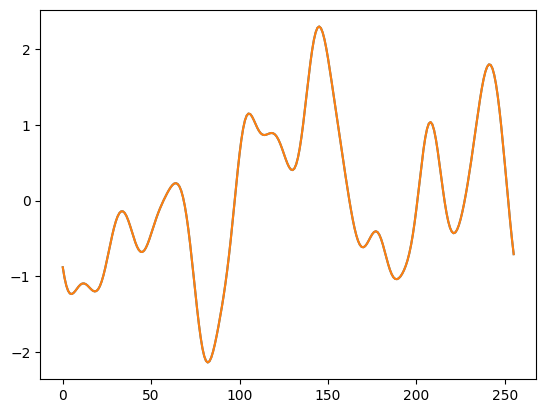

In [ ]:
plt.plot(x[0].detach().cpu() + 0.256 * (f0[0, :, :] - f1[0, :, :]).detach().cpu())
plt.plot(X[0, :, 0, :].detach().cpu())

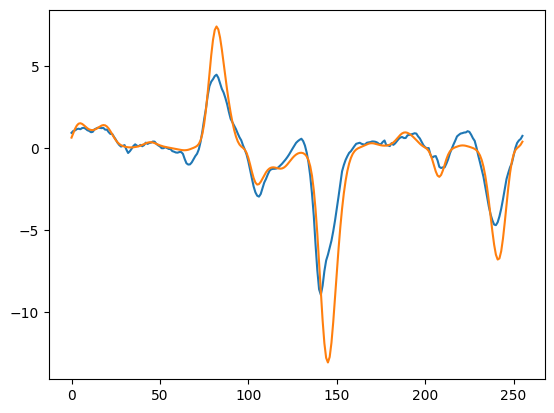

In [ ]:
plt.plot(MM.detach().cpu()[0, :, 0, 0])
plt.plot(dataset[:10, :, :, 1].unsqueeze(-1).detach().cpu()[0, :, 0, 0])

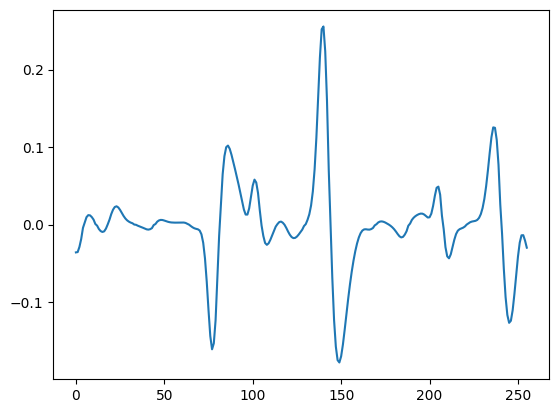

In [ ]:
plt.plot(
    dataset[:10, :, :, 0].unsqueeze(-1).detach().cpu()[0, :, 1, 0]
    - dataset[:10, :, :, 0].unsqueeze(-1).detach().cpu()[0, :, 0, 0]
)